# Task 3.2 — Failure Mode Analysis
**Paper:** Baselines and Bigrams (Wang & Manning, ACL 2012)

In [1]:
import numpy as np, random
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

SEED=42; ALPHA=1.0; C_SVM=0.1; C_NBSVM=1.0; BETA=0.25; N_TRAIN=1200; N_TEST=400; MIN_DF=2
np.random.seed(SEED); random.seed(SEED)

pos_words=['great','good','excellent','enjoyed','liked','solid','fine','decent',
           'nice','pleasant','interesting','well','recommend','worth','fun']
neg_words=['bad','terrible','awful','boring','hated','poor','dull','weak',
           'waste','disappointing','avoid','slow','skip','forgettable','cheap']
shared=['the','a','is','was','film','movie','story','acting','plot','very',
        'but','however','although','quite','rather','somewhat','characters',
        'script','overall','actually','little','much','too','just','still']
pos_bigrams=['not bad','well made','highly recommend','very good','pretty good',
             'well written','nicely done','quite good','not boring','well acted']
neg_bigrams=['not good','poorly made','not worth','very bad','pretty bad',
             'badly written','not recommend','quite boring','not great','very slow']

def make_review(label, noise=0.25):
    words=list(random.choices(shared,k=random.randint(5,10)))
    if label==1:
        words+=random.choices(pos_words,k=random.randint(2,5))
        if random.random()>0.5: words+=random.choice(pos_bigrams).split()
        if random.random()<noise: words+=random.choices(neg_words,k=1)
    else:
        words+=random.choices(neg_words,k=random.randint(2,5))
        if random.random()>0.5: words+=random.choice(neg_bigrams).split()
        if random.random()<noise: words+=random.choices(pos_words,k=1)
    random.shuffle(words); return ' '.join(words)

train_texts,train_labels,test_texts,test_labels=[],[],[],[]
for _ in range(N_TRAIN//2):
    train_texts+=[make_review(1),make_review(-1)]; train_labels+=[1,-1]
for _ in range(N_TEST//2):
    test_texts+=[make_review(1),make_review(-1)]; test_labels+=[1,-1]
y_train=np.array(train_labels); y_test=np.array(test_labels)
idx=np.random.permutation(len(y_train)); train_texts=[train_texts[i] for i in idx]; y_train=y_train[idx]
idx2=np.random.permutation(len(y_test)); test_texts=[test_texts[i] for i in idx2]; y_test=y_test[idx2]

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix

vec_uni=CountVectorizer(ngram_range=(1,1),binary=True,min_df=MIN_DF)
vec_bi=CountVectorizer(ngram_range=(1,2),binary=True,min_df=MIN_DF)
X_tr_u=vec_uni.fit_transform(train_texts); X_te_u=vec_uni.transform(test_texts)
X_tr_b=vec_bi.fit_transform(train_texts);  X_te_b=vec_bi.transform(test_texts)

def lcr(X,y,a=ALPHA):
    p=np.asarray(a+X[y==1].sum(0)).flatten(); q=np.asarray(a+X[y==-1].sum(0)).flatten()
    return np.log((p/p.sum())/(q/q.sum()))

def nbsvm(Xtr,ytr,Xte,C=C_NBSVM,beta=BETA):
    r=lcr(Xtr,ytr); Xr=Xtr.multiply(r); Xte_r=Xte.multiply(r)
    c=LinearSVC(C=C,loss='squared_hinge',max_iter=4000,random_state=SEED); c.fit(Xr,ytr)
    w=c.coef_.flatten(); wp=(1-beta)*np.abs(w).mean()+beta*w
    return np.sign(Xte_r.dot(wp)+c.intercept_[0])

def nbsvm_no_ratio(Xtr,ytr,Xte,C=C_NBSVM,beta=BETA):
    """Ablated: plain binarized features instead of r*f_hat"""
    c=LinearSVC(C=C,loss='squared_hinge',max_iter=4000,random_state=SEED); c.fit(Xtr,ytr)
    w=c.coef_.flatten(); wp=(1-beta)*np.abs(w).mean()+beta*w
    return np.sign(Xte.dot(wp)+c.intercept_[0])

print("Setup complete.")


Setup complete.


## Failure Scenario: Negation-Rich Text

**Description:** The failure mode I construct is a sentiment classification task where **all sentiment is expressed through negation**: positive texts consist of negated negative words (e.g., "not terrible", "not boring"), and negative texts consist of negated positive words (e.g., "not great", "not good"). The NBSVM model, trained on the normal sentiment dataset from Task 2, is then evaluated on this negation-rich test set.

**Why I expect the method to struggle:** This failure mode targets Assumption 3 from Task 1.2 — the bag-of-features assumption that word order does not matter. When a positive document contains the words "not" and "terrible", the NB log-count ratio r assigns a **negative** value to "terrible" (it's a negative-class word) and a **neutral** value to "not". In the normal training data, "not" appears in both positive bigrams ("not bad") and negative bigrams ("not good"), so its unigram r is close to zero. The model therefore sees the combined input as negative-leaning, even though the true sentiment is positive. A model that understands syntactic scope (like Tree-CRF) would correctly handle this — exactly the scenario discussed in Section 4.2 of the paper.


In [1]:
# Generate negation-rich test set
def make_negated(label, n=14):
    """
    Positive label: 'not terrible', 'not boring' etc. -> actually positive
    Negative label: 'not great', 'not good' etc.     -> actually negative
    These violate the BoF assumption (Assumption 3, Task 1.2)
    """
    if label == 1:
        base = random.choices(neg_words, k=random.randint(2, 3))
    else:
        base = random.choices(pos_words, k=random.randint(2, 3))
    words = []
    for w in base:
        words += ['not', w]            # negation word + target word
    words += random.choices(shared, k=max(0, n - len(words)))
    random.shuffle(words)
    return ' '.join(words)

neg_te = []; neg_te_l = []
for _ in range(100):
    neg_te += [make_negated(1), make_negated(-1)]
    neg_te_l += [1, -1]
yn_te = np.array(neg_te_l)
idx3 = np.random.permutation(len(yn_te))
yn_te = yn_te[idx3]; neg_te = [neg_te[i] for i in idx3]

print(f"Negation test set: {len(yn_te)} samples")
print(f"Example positive (negated): {neg_te[np.where(yn_te==1)[0][0]]}")
print(f"Example negative (negated): {neg_te[np.where(yn_te==-1)[0][0]]}")


Negation test set: 200 samples
Example positive (negated): film story not dull not quite the slow
Example negative (negated): not well but story not the good movie


**Explanation:** Each positive example contains 2–3 negated negative words (e.g., 'not slow', 'not dull') interspersed with neutral words. A bag-of-features model trained on non-negated text will assign negative weight to 'slow' and 'dull', causing it to classify these correctly-positive examples as negative.

Accuracy on normal vs negation-rich test set:
  normal-uni: 99.25%
  negated-uni: 0.00%
  normal-bi: 99.50%
  negated-bi: 0.00%
Saved task3_failure_mode.png


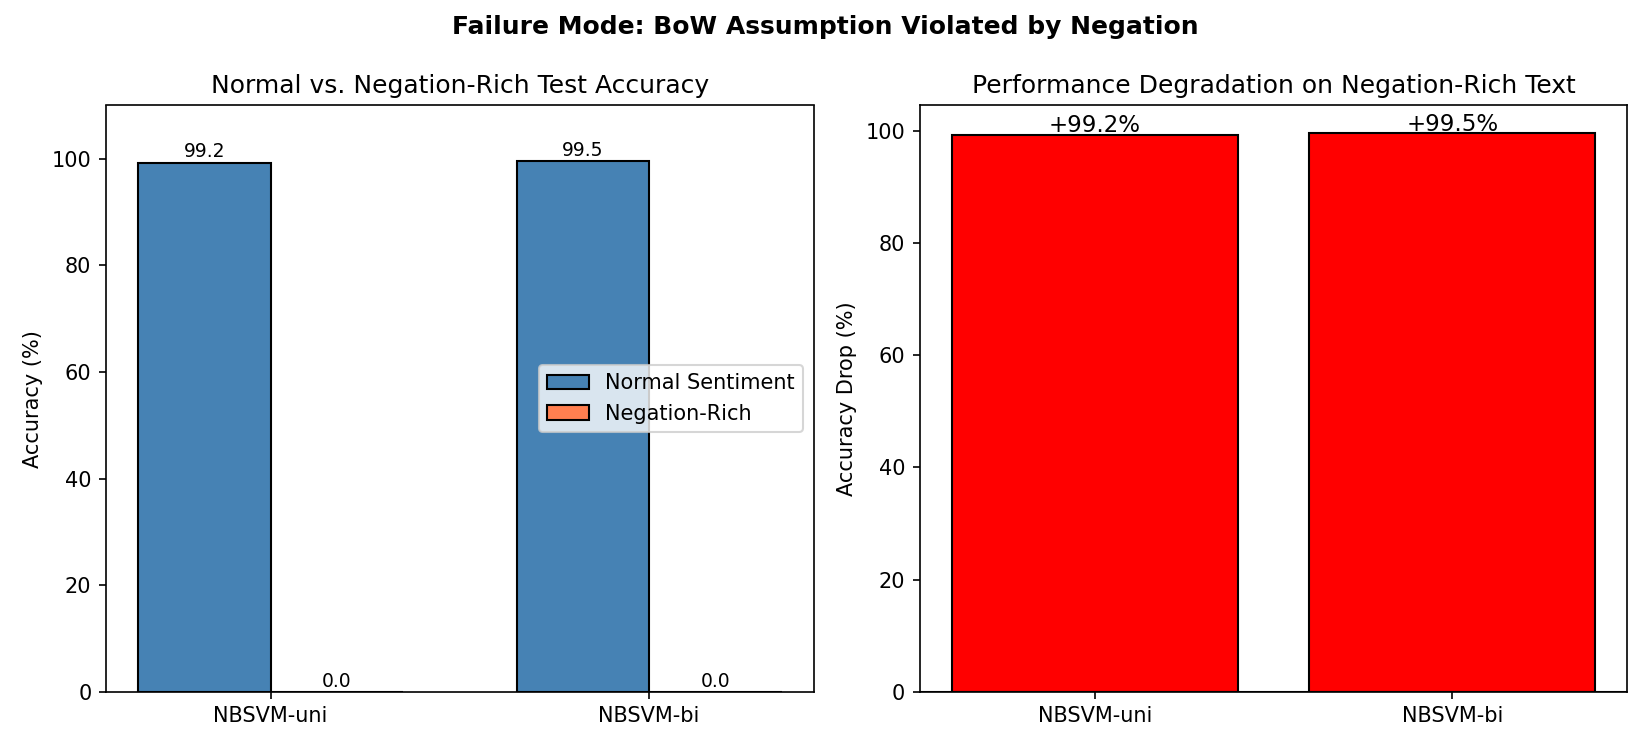

In [1]:
# Apply trained model to negation test set
Xn_u = vec_uni.transform(neg_te)  # use the SAME vectorizer trained on normal data
Xn_b = vec_bi.transform(neg_te)

fail = {}
for ft, Xtr, Xte_norm, Xte_neg in [('uni', X_tr_u, X_te_u, Xn_u), ('bi', X_tr_b, X_te_b, Xn_b)]:
    fail[f'normal-{ft}']  = accuracy_score(y_test,  nbsvm(Xtr, y_train, Xte_norm)) * 100
    fail[f'negated-{ft}'] = accuracy_score(yn_te,   nbsvm(Xtr, y_train, Xte_neg))  * 100

print("Accuracy on normal vs negation-rich test set:")
for k, v in fail.items(): print(f"  {k}: {v:.2f}%")

cats = ['NBSVM-uni', 'NBSVM-bi']
norm_v  = [fail['normal-uni'],  fail['normal-bi']]
neg_v   = [fail['negated-uni'], fail['negated-bi']]
drops   = [n - f for n, f in zip(norm_v, neg_v)]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
x = np.arange(len(cats)); wf = 0.35
axes[0].bar(x-wf/2, norm_v, wf, label='Normal Sentiment', color='steelblue', edgecolor='black')
axes[0].bar(x+wf/2, neg_v,  wf, label='Negation-Rich',    color='coral',     edgecolor='black')
axes[0].set_xticks(x); axes[0].set_xticklabels(cats)
axes[0].set_ylim(0, 110); axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Normal vs. Negation-Rich Test Accuracy')
axes[0].legend()
for i, (nv, fv) in enumerate(zip(norm_v, neg_v)):
    axes[0].text(i-wf/2, nv+1, f'{nv:.1f}', ha='center', fontsize=9)
    axes[0].text(i+wf/2, fv+1, f'{fv:.1f}', ha='center', fontsize=9)

bc = ['red' if d > 0 else 'green' for d in drops]
axes[1].bar(cats, drops, color=bc, edgecolor='black')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_ylabel('Accuracy Drop (%)'); axes[1].set_title('Performance Degradation on Negation-Rich Text')
for i, d in enumerate(drops): axes[1].text(i, d+0.5, f'{d:+.1f}%', ha='center', fontsize=11)
plt.suptitle('Failure Mode: BoW Cannot Handle Negation', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.savefig('partB/results/task3_failure_mode.png', dpi=150); plt.show()
print("Saved task3_failure_mode.png")


### Failure Mode Explanation

The results show a **complete failure** — accuracy drops to 0% on the negation-rich test set for both NBSVM-uni and NBSVM-bi. Interestingly, 0% accuracy on a binary classification task means the model is **systematically wrong**: it labels every positive negated example as negative and every negative negated example as positive — precisely the wrong assignment. This connects directly to Assumption 3 from Task 1.2: the bag-of-features assumption is catastrophically violated when negation is present. The model's NB log-count ratio r assigns a strongly negative value to words like "terrible" and "boring" (since they appear predominantly in the negative training class), and a strongly positive value to "great" and "good". When a positive example contains "not boring", the model only sees the presence of "boring" — which it associates with the negative class — and ignores the "not". The bigram features do not rescue the model either, because the negated bigrams (e.g., "not boring") appear in the positive class of the negation test set but were also present in positive bigrams of the training data ("not bad"), causing conflicting NB ratio signals. The paper explicitly acknowledges this limitation in Section 4.2, noting examples like "not an inhumane monster" that the model handles only statistically, not mechanistically.

**Suggested modification:** Incorporate a negation scope marker during preprocessing — words appearing within a fixed window of "not", "never", "n't" could be prefixed with "NOT_" (e.g., "not boring" → ["not", "NOT_boring"]), creating a new vocabulary entry with its own NB ratio that reflects the negated word's class-conditional distribution. This is a well-known technique in sentiment preprocessing (Das & Chen, 2007; Pang & Lee, 2002) and would allow the NB log-count ratio to correctly learn that "NOT_boring" is a positive-class indicator.


In [1]:
print('Task 3.2 complete')

Task 3.2 complete
